In [ ]:
%%capture
!pip install --upgrade scikit-learn
!pip install --upgrade gensim
!apt-get install git

In [ ]:
%%capture
!git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git

In [ ]:
from google.colab import files
import pandas as pd
import re
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import gensim
import gensim.downloader

import seaborn as sns
import matplotlib.pyplot as plt

def Preprocess(Text):
    msg = re.sub('[^a-zA-Z]', ' ', Text)
    msg = msg.lower()
    msg = msg.split()
    msg = ' '.join(msg)
    return msg

In [ ]:
FTX = gensim.downloader.load('fasttext-wiki-news-subwords-300')

[==================================================] 100.0% 958.5/958.4MB downloaded


In [ ]:
trainset = pd.read_csv("SST-2-sentiment-analysis/data/train.tsv", sep='\t', header=None, names=["class", "review"])
testset = pd.read_csv("SST-2-sentiment-analysis/data/test.tsv", sep='\t', header=None, names=["class", "review"])
trainset["p-review"] = trainset["review"].apply(Preprocess)
testset["p-review"] = testset["review"].apply(Preprocess)


In [ ]:
dim = FTX.vector_size
nTrain = round(len(trainset) * 0.8)

TrainVecs = []
TestVecs = []
print(dim)
for msg in trainset["p-review"]:
  words = msg.split()
  x = np.zeros((len(words), dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TrainVecs.append(torch.FloatTensor(x))

DevVecs = TrainVecs[nTrain:]
TrainVecs = TrainVecs[:nTrain]

for msg in testset["p-review"]:
  words = msg.split()
  x = np.zeros((len(words), dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TestVecs.append(torch.FloatTensor(x))


CTrain = trainset["class"][:nTrain]
CDev = trainset["class"][nTrain:]
CTest = testset["class"]
print(len(CTrain), len(CDev), len(CTest))

300
5536 1384 1821


In [ ]:
dim = FTX.vector_size
nTrain = round(len(trainset) * 0.8)

TrainVecs = []
TestVecs = []
print(dim)
for msg in trainset["p-review"]:
  words = msg.split()
  nwords = len(words)
  if nwords < 5:
    nwords = 5
  x = np.zeros((nwords, dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TrainVecs.append(x)

DevVecs = TrainVecs[nTrain:]
TrainVecs = TrainVecs[:nTrain]

for msg in testset["p-review"]:
  words = msg.split()
  nwords = len(words)
  if nwords < 5:
    nwords = 5
  x = np.zeros((nwords, dim))
  for i in range(len(words)):
    if FTX.has_index_for(words[i]):
      x[i] = FTX[words[i]]
  TestVecs.append(x)


CTrain = trainset["class"][:nTrain]
CDev = trainset["class"][nTrain:]
CTest = testset["class"]
print(len(CTrain), len(CDev), len(CTest))

300
5536 1384 1821


In [ ]:
def toBatch(vecs, cls, batchsize=8, dim=dim):
  vecbatches = []
  clsbatches = []
  nvecs = len(vecs)
  for idx in range(nvecs // batchsize):
    maxlen = 0
    for i in range(batchsize):
      slen = len(vecs[idx * batchsize + i])
      if maxlen < slen:
        maxlen = slen
    vecbatch = np.zeros((batchsize, maxlen, dim))
    clsbatch = np.zeros((batchsize))
    for i in range(batchsize):
      clsbatch[i] = cls[idx * batchsize + i]
      slen = len(vecs[idx * batchsize + i])
      if slen < maxlen:
        pad = np.zeros((maxlen - slen, dim))
        vecbatch[i] = np.vstack((vecs[idx * batchsize + i], pad))
      else:
        vecbatch[i] = vecs[idx * batchsize + i]
    vecbatches.append(torch.FloatTensor(vecbatch))
    clsbatches.append(torch.LongTensor(clsbatch))
  return vecbatches, clsbatches


In [ ]:
VecBatches, ClsBatches = toBatch(TrainVecs, CTrain)
TVecBatches, TClsBatches = toBatch(TestVecs, CTest)

Hiệu quả phân lớp khi sử dụng Count Vectorizer

In [ ]:
class Attention(nn.Module):

    def __init__(self, dim):
        super().__init__()

        # attention vector
        self.Va = nn.Parameter(torch.randn(dim) * 0.01)

    def forward(self, word_vectors):
        """
        word_vectors: (seq_len, embed_dim)
        """
        '''
        # attention scores
        print("Word Vectors", word_vectors.shape)
        scores = torch.matmul((word_vectors, self.Va)

        # scale like transformer
        scores = scores / (word_vectors.shape[-1] ** 0.5)

        # stable softmax
        scores = scores - scores.max().detach()

        weights = torch.softmax(scores, dim=0)

        # weighted sum
        comment_vector = torch.sum(weights.unsqueeze(2) * word_vectors, dim=0)
        '''
        scores = torch.matmul(word_vectors, self.Va)   # (B, T)

        # scale
        scores = scores / (word_vectors.shape[-1] ** 0.5)

        # stable softmax per sentence
        scores = scores - scores.max(dim=1, keepdim=True)[0]

        weights = torch.softmax(scores, dim=1)          # (B, T)

        # weighted sum
        comment_vector = torch.sum(weights.unsqueeze(-1) * word_vectors, dim=1)

        return comment_vector, weights


# ---------------------------
# Classifier
# ---------------------------

class AttentionClassifier(nn.Module):

    def __init__(self, embed_dim, num_classes):
        super().__init__()

        self.attention = Attention(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, word_vectors):

        vec, weights = self.attention(word_vectors)

        logits = self.fc(vec)   # NO softmax here

        return logits, weights


# ---------------------------
# Example Training Script
# ---------------------------

model = AttentionClassifier(dim, 2)

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

criterion = nn.CrossEntropyLoss()
step = 0
for epoch in range(20):
  for X, Y in zip(VecBatches, ClsBatches):
    optimizer.zero_grad()

    output, weights = model(X)
    loss = criterion(output, Y)

    loss.backward()

    #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    if (step % 500 == 0):
      print(step, loss.item())
    step += 1


0 0.6940158009529114
500 0.6132238507270813
1000 0.6108628511428833
1500 0.6526491641998291
2000 0.5632035732269287
2500 0.3858119547367096
3000 0.6296921968460083
3500 0.29003041982650757
4000 0.5585781335830688
4500 0.6972106695175171
5000 0.41907206177711487
5500 0.534389078617096
6000 0.582381546497345
6500 0.2400360405445099
7000 0.5008216500282288
7500 0.34483006596565247
8000 0.6696574687957764
8500 0.3321581184864044
9000 0.4397423565387726
9500 0.2738235294818878
10000 0.4252511262893677
10500 0.2935280501842499
11000 0.23964247107505798
11500 0.5670978426933289
12000 0.44766128063201904
12500 0.4014767110347748
13000 0.2788679003715515
13500 0.33218738436698914


In [ ]:
def show_attention(sentence, weights):
  words = sentence.split()
  fig, ax = plt.subplots(figsize=(len(words)*0.36 + 0.81 , 0.36), dpi=100)
  sns.heatmap([weights.detach().cpu().numpy()], ax=ax, cmap="Reds", cbar=False, xticklabels=words, yticklabels=[], linewidths=0.5)
  plt.show()

/tmp/ipykernel_559/1187485923.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  output, weights = model(torch.FloatTensor([TestVecs[isample]]))


0


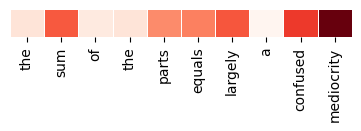

In [ ]:
isample = 53
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])

0


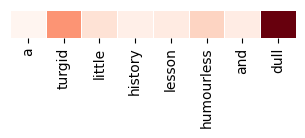

In [ ]:
isample = 67
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])

1


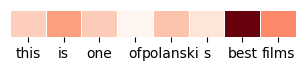

In [ ]:
isample = 4
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])


1


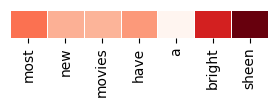

In [ ]:
isample = 20
output, weights = model(torch.FloatTensor([TestVecs[isample]]))
print(testset["class"][isample])
show_attention(testset["p-review"][isample], weights[0])

In [ ]:
model.train(False)
ncorrect = 0
nsamples = 0
for X, Y in zip(TVecBatches, TClsBatches):
  output, weights = model(X)
  plabel = output.argmax(dim=-1)

  for l,pl in zip(Y.detach().numpy(), plabel.detach().numpy()):
    nsamples += 1
    if l == pl:
      ncorrect += 1

print("Accuracy", ncorrect/nsamples)


Accuracy 0.808920704845815
